In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
n = pypsa.Network("../../results/cost_year~2030/transport_cost~custom/demand~1/product~steel/network.nc")

INFO:pypsa.network.io:New version 0.35.1 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads


In [3]:
n.objective / 1e9

1055.254441657586

In [4]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator iron_ore               2.627644e+09                 0.0   
Link      shipping_iron_ore      1.352168e+09                 0.0   
          shipping_steel         1.761223e+09                 0.0   
          steel                  2.627644e+09                 0.0   
Load      -                      0.000000e+00                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator iron_ore           2.627644e+09  0.000000e+00    2.627644e+09   
Link      shipping_iron_ore  0.000000e+00  1.352168e+09   -1.352168e+09   
          shipping_steel     0.000000e+00  1.761223e+09   -1.761223e+09   
          steel              0.000000e+00  2.627644e+09   -2.627644e+09   
Load      -                  0.000000e+00  1.635265e+09   -1.635265e+09   

                             Transmission  Capacity Factor  Curtailment  \
Generator iron_ore           0.000000e+00              1.0          0.0   
Link      shipping_iron_ore  1.352168e+09              1.0          0.0   
          shipping_steel     1.761223e+09              1.0          0.0   
          steel              0.000000e+00              1.0          0.0   
Load      -                  0.000000e+00              NaN          0.0   

                             Capital Expenditure  Operational Expenditure  \
Generator iron_ore                  2.627644e+06             2.567208e+11   
Link      shipping_iron_ore         1.352168e+06             1.954297e+10   
          shipping_steel            1.761223e+06             0.000000e+00   
          steel                     2.627644e+06             7.789823e+11   
Load      -                         0.000000e+00             0.000000e+00   

                                  Revenue  Market Value  
Generator iron_ore           2.804954e+11    106.747859  
Link      shipping_iron_ore -1.497858e+11           NaN  
          shipping_steel    -1.164279e+12           NaN  
          steel             -3.000397e+11           NaN  
Load      -                 -1.093127e+12           NaN

In [5]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator iron_ore               2.627644e+09                 0.0   
Link      shipping_iron_ore      1.352168e+09                 0.0   
          shipping_steel         1.761223e+09                 0.0   
          steel                  2.627644e+09                 0.0   
Load      -                      0.000000e+00                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator iron_ore           2.627644e+09  0.000000e+00    2.627644e+09   
Link      shipping_iron_ore  0.000000e+00  1.352168e+09   -1.352168e+09   
          shipping_steel     0.000000e+00  1.761223e+09   -1.761223e+09   
          steel              0.000000e+00  2.627644e+09   -2.627644e+09   
Load      -                  0.000000e+00  1.635265e+09   -1.635265e+09   

                             Transmission  Capacity Factor  Curtailment  \
Generator iron_ore           0.000000e+00              1.0          0.0   
Link      shipping_iron_ore  1.352168e+09              1.0          0.0   
          shipping_steel     1.761223e+09              1.0          0.0   
          steel              0.000000e+00              1.0          0.0   
Load      -                  0.000000e+00              NaN          0.0   

                             Capital Expenditure  Operational Expenditure  \
Generator iron_ore                  2.627644e+06             2.567208e+11   
Link      shipping_iron_ore         1.352168e+06             1.954297e+10   
          shipping_steel            1.761223e+06             0.000000e+00   
          steel                     2.627644e+06             7.789823e+11   
Load      -                         0.000000e+00             0.000000e+00   

                                  Revenue  Market Value  
Generator iron_ore           2.804954e+11    106.747859  
Link      shipping_iron_ore -1.497858e+11           NaN  
          shipping_steel    -1.164279e+12           NaN  
          steel             -3.000397e+11           NaN  
Load      -                 -1.093127e+12           NaN

In [6]:
n.statistics.energy_balance()

component  carrier         bus_carrier
Generator  iron_ore        iron_ore       2.627644e+09
Link       shipping_steel  steel         -1.734173e+07
           steel           iron_ore      -2.627644e+09
                           steel          1.652606e+09
Load       -               steel         -1.635265e+09
dtype: float64

### Global supply, demand and trade

#### Supply

In [7]:
supply = n.statistics.energy_balance(comps=["Generator"], groupby=["bus"]).div(1e6)
supply.sort_values(ascending=False)

component  bus                    
Generator  Oceania_ore                973.076393
           South_America_ore          414.967813
           East_Asia_ore              336.000000
           West_Asia_ore              324.000000
           Eurasia_ore                169.200000
           Europe_ore                 109.200000
           Middle_East_ore             92.400000
           North_America_ore           84.000000
           Subsaharan_Africa_ore       73.200000
           South_South_America_ore     21.600000
           North_West_Africa_ore       15.600000
           Central_America_ore         14.400000
Name: generators, dtype: float64

In [8]:
print(f"The total supply is {supply.sum():.2f} Mt")

The total supply is 2627.64 Mt


In [34]:
# Most expensive supply of steel
n.links[n.links.carrier == "steel"].marginal_cost.sort_values() *1.59 + (98* 1.59) #.describe()*1.59

Link
steel supply West_Asia_1        569.865305
steel supply East_Asia_1        573.923152
steel supply West_Asia_2        574.351587
steel supply West_Asia_3        578.466343
steel supply East_Asia_2        579.806499
                                   ...    
steel supply Pacific_Asia_45    788.231403
steel supply Pacific_Asia_50    809.809940
steel supply Pacific_Asia_55    827.747992
steel supply Pacific_Asia_60    842.819939
steel supply Pacific_Asia_65    855.722432
Name: marginal_cost, Length: 200, dtype: float64

#### Demand

In [10]:
demand = n.statistics.energy_balance(comps=["Load"], groupby=["bus"]).div(-1e6)
demand.sort_values(ascending=False)

component  bus                
Load       East_Asia              1000.050000
           West_Asia               146.043000
           Europe                  116.179594
           East_East_Asia           87.000000
           Eurasia                  80.481164
           Middle_East              49.403400
           South_America            38.800200
           Pacific_Asia             32.836399
           Central_America          20.360100
           Far_West_Europe          19.325100
           North_West_Africa        15.591300
           North_America            12.000000
           Oceania                   6.236934
           South_South_America       5.801100
           Subsaharan_Africa         5.156400
Name: objective, dtype: float64

In [11]:
print(f"The total demand is {demand.sum():.2f} Mt")

The total demand is 1635.26 Mt


#### Trade

In [12]:
trade = n.statistics.energy_balance(comps=["Link"], groupby=["bus", "carrier"]).div(1e6)
trade

component  bus                      carrier          
Link       Central_America          shipping_steel        20.360100
           Central_America_ore      shipping_iron_ore    -14.400000
           East_Asia                shipping_steel       788.729245
                                    steel                211.320755
           East_Asia_ore            steel               -336.000000
           East_East_Asia           shipping_steel        87.000000
           Eurasia                  shipping_steel       -25.933930
                                    steel                106.415094
           Eurasia_ore              steel               -169.200000
           Europe                   shipping_steel       116.179594
           Europe_ore               shipping_iron_ore   -109.200000
           Far_West_Europe          shipping_steel        19.325100
           Middle_East              shipping_steel        49.403400
           Middle_East_ore          shipping_iron_ore    -92.4

In [13]:
trade.sum()

-992.37951546763

Exporters

In [14]:
exporters = trade[trade < 0] * (-1)
exporters.sort_values(ascending=False)

component  bus                      carrier          
Link       Oceania_ore              steel                973.076393
           North_West_Africa_ore    steel                963.906689
           Oceania                  shipping_steel       605.760797
           North_West_Africa        shipping_steel       590.639322
           South_America_ore        shipping_iron_ore    414.967813
           East_Asia_ore            steel                336.000000
           West_Asia_ore            shipping_iron_ore    324.000000
           Eurasia_ore              steel                169.200000
           Europe_ore               shipping_iron_ore    109.200000
           North_America_ore        steel                 98.400000
           Middle_East_ore          shipping_iron_ore     92.400000
           South_South_America_ore  steel                 87.061124
           Subsaharan_Africa_ore    shipping_iron_ore     73.200000
           North_America            shipping_steel        49.8

Importers

In [15]:
importers = trade[trade > 0]
importers.sort_values(ascending=False)

component  bus                      carrier          
Link       North_West_Africa_ore    shipping_iron_ore    948.306689
           East_Asia                shipping_steel       788.729245
           Oceania                  steel                611.997731
           North_West_Africa        steel                606.230622
           East_Asia                steel                211.320755
           West_Asia                shipping_steel       146.043000
           Europe                   shipping_steel       116.179594
           Eurasia                  steel                106.415094
           East_East_Asia           shipping_steel        87.000000
           South_South_America_ore  shipping_iron_ore     65.461124
           North_America            steel                 61.886792
           South_South_America      steel                 54.755424
           Middle_East              shipping_steel        49.403400
           South_America            shipping_steel        38.8

### Iron ore

In [16]:
n.statistics.energy_balance(comps=["Link"], groupby=["bus", "carrier"]).div(1e6).loc[:,:,"shipping_iron_ore"]

component  bus                    
Link       Central_America_ore        -14.400000
           Europe_ore                -109.200000
           Middle_East_ore            -92.400000
           North_America_ore           14.400000
           North_West_Africa_ore      948.306689
           South_America_ore         -414.967813
           South_South_America_ore     65.461124
           Subsaharan_Africa_ore      -73.200000
           West_Asia_ore             -324.000000
Name: objective, dtype: float64

In [17]:
n.statistics.energy_balance(comps=["Generator"], groupby=["bus", "carrier"]).div(1e6)

component  bus                      carrier 
Generator  Central_America_ore      iron_ore     14.400000
           East_Asia_ore            iron_ore    336.000000
           Eurasia_ore              iron_ore    169.200000
           Europe_ore               iron_ore    109.200000
           Middle_East_ore          iron_ore     92.400000
           North_America_ore        iron_ore     84.000000
           North_West_Africa_ore    iron_ore     15.600000
           Oceania_ore              iron_ore    973.076393
           South_America_ore        iron_ore    414.967813
           South_South_America_ore  iron_ore     21.600000
           Subsaharan_Africa_ore    iron_ore     73.200000
           West_Asia_ore            iron_ore    324.000000
Name: generators, dtype: float64

### Cost

In [18]:
print(f"The total cost is {n.objective/1e9:.2f} B EUR")

The total cost is 1055.25 B EUR


In [19]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator iron_ore               2.627644e+09                 0.0   
Link      shipping_iron_ore      1.352168e+09                 0.0   
          shipping_steel         1.761223e+09                 0.0   
          steel                  2.627644e+09                 0.0   
Load      -                      0.000000e+00                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator iron_ore           2.627644e+09  0.000000e+00    2.627644e+09   
Link      shipping_iron_ore  0.000000e+00  1.352168e+09   -1.352168e+09   
          shipping_steel     0.000000e+00  1.761223e+09   -1.761223e+09   
          steel              0.000000e+00  2.627644e+09   -2.627644e+09   
Load      -                  0.000000e+00  1.635265e+09   -1.635265e+09   

                             Transmission  Capacity Factor  Curtailment  \
Generator iron_ore           0.000000e+00              1.0          0.0   
Link      shipping_iron_ore  1.352168e+09              1.0          0.0   
          shipping_steel     1.761223e+09              1.0          0.0   
          steel              0.000000e+00              1.0          0.0   
Load      -                  0.000000e+00              NaN          0.0   

                             Capital Expenditure  Operational Expenditure  \
Generator iron_ore                  2.627644e+06             2.567208e+11   
Link      shipping_iron_ore         1.352168e+06             1.954297e+10   
          shipping_steel            1.761223e+06             0.000000e+00   
          steel                     2.627644e+06             7.789823e+11   
Load      -                         0.000000e+00             0.000000e+00   

                                  Revenue  Market Value  
Generator iron_ore           2.804954e+11    106.747859  
Link      shipping_iron_ore -1.497858e+11           NaN  
          shipping_steel    -1.164279e+12           NaN  
          steel             -3.000397e+11           NaN  
Load      -                 -1.093127e+12           NaN

In [20]:
n.generators.marginal_cost

Generator
Europe_ore                 97.7
Far_West_Europe_ore        97.7
Middle_East_ore            97.7
North_West_Africa_ore      97.7
Subsaharan_Africa_ore      97.7
North_America_ore          97.7
Eurasia_ore                97.7
South_America_ore          97.7
South_South_America_ore    97.7
Central_America_ore        97.7
West_Asia_ore              97.7
East_Asia_ore              97.7
Pacific_Asia_ore           97.7
East_East_Asia_ore         97.7
Oceania_ore                97.7
Name: marginal_cost, dtype: float64

In [21]:
n.links.p_nom_opt.sort_values(ascending=False)

Link
shipping Oceania-East_Asia                           5.726263e+08
iron ore shipping Middle_East-North_West_Africa      4.164000e+08
iron ore shipping South_America-North_West_Africa    3.495067e+08
iron ore shipping West_Asia-Middle_East              3.240000e+08
steel supply North_West_Africa_15                    2.973994e+08
                                                         ...     
steel supply East_East_Asia_40                       0.000000e+00
steel supply East_East_Asia_45                       0.000000e+00
steel supply East_East_Asia_50                       0.000000e+00
steel supply East_East_Asia_55                       0.000000e+00
steel supply East_East_Asia_15                       0.000000e+00
Name: p_nom_opt, Length: 620, dtype: float64

### Sankey

### Global map

In [22]:
plot_config = {"bus_size": 1.0e-7,
               "link_width": 1.5e-8,}

In [23]:
product = "steel"

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_trade_map(n, supply, demand, trade, plot_config,
                   supply_color="black", demand_color="lightsteelblue",
                   link_colors="gray", alpha_supply=0.7, alpha_demand=1):

    fig = plt.figure(figsize=(10, 5))

    # Plot demand
    n.plot.map(
        bus_sizes=demand * plot_config["bus_size"],
        bus_colors=demand_color,
        bus_alpha=alpha_demand,
        link_widths=0,
        branch_components=["Link"],
    )

    # Plot supply
    n.plot.map(
        bus_sizes=supply * plot_config["bus_size"],
        bus_colors=supply_color,
        bus_alpha=alpha_supply,
        link_widths=trade * plot_config["link_width"],
        branch_components=["Link"],
        link_colors=link_colors,
    )

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], color=link_colors, label="shipping"),
        plt.Line2D([0], [0], marker="o", color="white", label="Demand",
                   markerfacecolor=demand_color, markersize=10),
        plt.Line2D([0], [0], marker="o", color="white", label="Supply",
                   markerfacecolor=supply_color, markersize=10),
    ]
    fig.legend(
        handles=legend_elements,
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(0.22, 0.28),
    )

    return fig


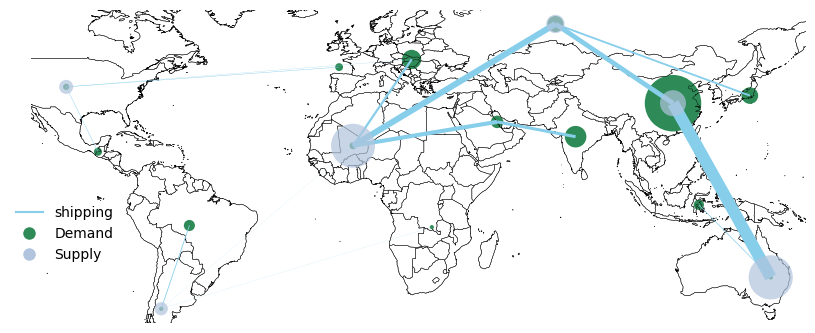

In [25]:
# Supply and demand
region_gen = n.statistics.supply(comps=["Link"], groupby=["bus", "carrier"]).loc[:, :, "steel"].droplevel(0)
region_load = n.loads.groupby("bus").p_set.sum()
steel_trade = n.links[n.links.carrier == "shipping_steel"].p_nom_opt.astype(int)

# Link colors
color_shipping_iron_ore = "skyblue"

# Plot
fig = plot_trade_map(
    n,
    supply=region_gen,
    demand=region_load,
    trade=steel_trade,
    plot_config=plot_config,
    supply_color="lightsteelblue",
    demand_color="seagreen",
    link_colors=color_shipping_iron_ore,
    alpha_supply=0.7
)

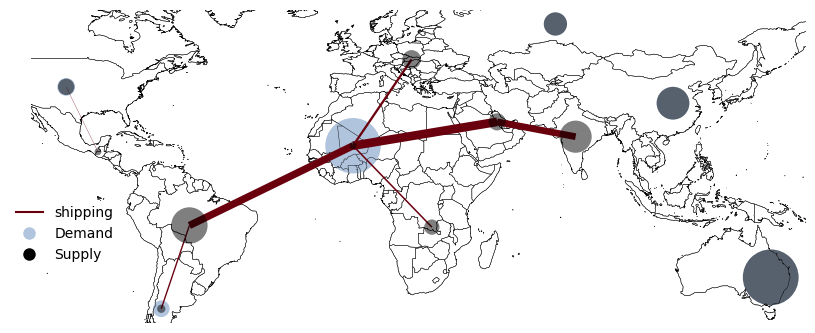

In [26]:
# Supply and demand
iron_ore_gen = n.statistics.supply(comps=["Generator"], groupby=["bus", "carrier"]).loc[:, :, "iron_ore"].droplevel(0)
steel_load = n.statistics.withdrawal(comps=["Link"], groupby=["bus", "carrier"]).loc[:, :, "steel"].droplevel(0)
iron_ore_trade = n.links[n.links.carrier == "shipping_iron_ore"].p_nom_opt.astype(int)

# Shipping color from carrier
color_shipping_iron_ore = n.carriers.loc["shipping_iron_ore", "color"]

# Plot
fig = plot_trade_map(
    n,
    supply=iron_ore_gen,
    demand=steel_load,
    trade=iron_ore_trade,
    plot_config=plot_config,
    supply_color="black",
    demand_color="lightsteelblue",
    link_colors=color_shipping_iron_ore,
    alpha_supply=0.5
)
